In [1]:
import pynbody as pn
import matplotlib
matplotlib.rcParams['animation.ffmpeg_path'] = '/opt/homebrew/bin/ffmpeg'
import matplotlib.pyplot as plt
import numpy as np
import pynbody.filt as filt
from pynbody.analysis import profile
import os
from matplotlib.animation import FuncAnimation
from scipy.stats import gaussian_kde
from scipy import optimize
from scipy import interpolate
from scipy.interpolate import UnivariateSpline
from scipy.ndimage import maximum_filter
from scipy.special import gamma, factorial
from scipy.integrate import nquad
from scipy.integrate import cumulative_trapezoid
import scipy.special as sc
from scipy.spatial import cKDTree
from scipy.special import gamma, factorial
import scipy.integrate as integrate
G = 4.302e-3 #pc/M_sol/km/s**2
a0 = 1.2e-10 # m/s**2
a0_kms_pc = 1.2e-10 * (1e-3)**2 * 3.086e16

def v_inf(M):
    # returns km/s
    return (G * M * a0_kms_pc) ** (1/4)

def g_ext(R_kpc, M):
    R_pc = R_kpc * 1e3
    gN   = G * M / R_pc**2
    return nu_mond(gN / a0_kms_pc) * gN

def nu_mond(y):
    return 1/2 + np.sqrt(1/4 + 1/y)

def sersic_a(r_e, n):
    return r_e * np.exp(0.1789 - 0.6950*n - n * np.log(n))

def sersic_p(n):
    return 1 - 0.6097/n + 0.05563/n**2

def sersic_mass(r, M, n, r_e):
    p = sersic_p(n)
    a = sersic_a(r_e, n)
    s = 3*n - n*p
    ra = (r/a)**(1/n)
    return M * sc.gammainc(s, ra) 

def sersic_rho_0(M, n, r_e): 
    gam = gamma(3 * n - n * sersic_p(n))
    return M/(4 * np.pi * n * sersic_a(r_e, n)**3 * gam)
    
def sersic_density(r, M, n, r_e):
    ra = r/sersic_a(r_e, n)
    return sersic_rho_0(M, n, r_e) * (ra)**(-sersic_p(n)) * np.exp(-(ra)**(1/n))
    
def g_newton(r, M_enc):
    return G * M_enc / r**2  

def g_mond_efe(r_pc_array, M_enc_array, R_kpc, M_host):
    gN      = g_newton(r_pc_array, M_enc_array)
    R_pc    = R_kpc * 1e3
    gNe     = G * M_host / R_pc**2
    g_N_tot = gN + gNe
    nu_tot      = nu_mond(g_N_tot / a0_kms_pc)
    return nu_tot * gN + gNe * (nu_tot - nu_mond(gNe / a0_kms_pc))

def g_mond(r_pc_array, M_enc_array):
    #QUOMOND
    gN = g_newton(r_pc_array, M_enc_array)
    return nu_mond(gN / a0_kms_pc) * gN

def mond_potential_efe(r_array, mass_enc_array, R_kpc, M_host, n_ext=200):
    r_array        = np.maximum(np.asarray(r_array, dtype=float), 1.0)  # 1pc floor only
    mass_enc_array = np.asarray(mass_enc_array, dtype=float)
    M_tot  = float(mass_enc_array[-1])
    r_max  = float(r_array[-1])
    R_pc   = R_kpc * 1e3
    gNe    = G * M_host / R_pc**2
    r_efe_pc = v_inf(M_tot)**2 / gNe

    r_cutoff = max(r_efe_pc * 10, r_max * 3)
    r_tail   = np.linspace(r_max, r_cutoff, n_ext)

    g_tail   = g_mond_efe(r_tail,   M_tot, R_kpc, M_host)
    g_main   = g_mond_efe(r_array,  mass_enc_array, R_kpc, M_host)

    phi_tail = cumulative_trapezoid(g_tail[::-1], r_tail[::-1], initial=0)[::-1]
    phi_main = cumulative_trapezoid(g_main[::-1], r_array[::-1], initial=0)[::-1]
    phi_main += phi_tail[0]

    return phi_main

def mond_potential_bound(r_array, mass_enc_array, n_ext=200):
    """
    Potential for bound mass calculation. 
    """
    r_array        = np.maximum(np.asarray(r_array, dtype=float), 1.0)
    r_max = np.max(r_array)
    mass_enc_array = np.asarray(mass_enc_array, dtype=float)
    
    r_cutoff = max(r_array * 10, r_max * 3)
    r_tail   = np.linspace(r_max, r_cutoff, n_ext)
    M_tot = mass_enc_array[-1]
    
    g_tail   = g_mond(r_tail, M_tot)
    g_arr = g_mond(r_array, mass_enc_array)
    
    phi   = cumulative_trapezoid(g_arr[::-1], r_array[::-1], initial=0)[::-1]
    phi_tail = cumulative_trapezoid(g_tail[::-1], r_tail[::-1], initial=0)[::-1]
    
    phi += phi_tail[0]
    
    return phi

def sigma_integrand_newton(r_prime, M, n, r_e): 
    return sersic_density(r_prime, M, n, r_e) * g_newton(r_prime, sersic_mass(r_prime, M, n, r_e))

def sigma_integrand_mond(r_prime, M, n, r_e):
    return sersic_density(r_prime, M, n, r_e) * g_mond(r_prime, sersic_mass(r_prime, M, n, r_e))

def sigma_integrand_efe(r_prime, M, n, r_e, R, M_host):
    return sersic_density(r_prime, M, n, r_e) * g_mond_efe(r_prime, sersic_mass(r_prime, M, n, r_e), R, M_host)

def get_sigma(r, M, a_p, n, r_e, profile, R, M_host, r_cut = None, mond=True, n_table=10000, efe = False):
    if profile == "sersic":
        if r_cut is None:
            r_max_int = 50 * r_e 
        else:
            r_max_int = r_cut

        r_grid_end = max(20 * r_e, r_max_int) 
        r_grid = np.geomspace(1e-3 * r_e, r_grid_end, n_table)
        
        def sigma_sq_at_r(r0):
            if mond and efe:
                integral, _ = integrate.quad(
                    sigma_integrand_efe, r0, r_max_int, 
                    args=(M, n, r_e, R, M_host), limit=200
                )
            elif mond:
                integral, _ = integrate.quad(
                    sigma_integrand_mond, r0, r_max_int, 
                    args=(M, n, r_e), limit=200
                )
            else:
                integral, _ = integrate.quad(
                    sigma_integrand_newton, r0, r_max_int, 
                    args=(M, n, r_e), limit=200)
                
            return integral / sersic_density(r0, M, n, r_e)
        
        sigma_grid = np.sqrt([sigma_sq_at_r(r0) for r0 in r_grid])
        sigma_interp = interpolate.interp1d(r_grid, sigma_grid, bounds_error=False, fill_value=(sigma_grid[0], sigma_grid[-1]))
        return sigma_interp(r)
    
def get_beta(v, r, R, M):
    # Brada 2000
    # EFE importance: beta << 1 means EFE dominated
    v   = float(v)
    r   = float(r)*1e3
    R   = float(R)*1e3
    M   = float(M)
    return (v**2 * R) / (v_inf(M)**2 * r)

def get_alpha(v, r, R, M):
    # Brada 2000
    # Tidal importance: alpha << 1 means tidal dominated
    v   = float(v)
    r   = float(r)  
    R   = float(R) 
    M   = float(M)
    return (v * R / (r * v_inf(M))) ** (2/3)
    
def mask_bound(snapshot, center, r_cut):
    pos = np.array(snapshot["pos"], dtype=float)
    center = np.asarray(center, dtype=float).flatten()
    r = np.sqrt(((pos - center)**2).sum(axis=1))
    mask = r < r_cut
    print(f"{mask.sum()} particles within {r_cut} kpc of {center}")
    return mask

def lagrangian_radius(snapshot, center, fraction=0.99):
    pos  = snapshot["pos"]
    mass = snapshot["mass"]
    center = np.asarray(center, dtype=float).flatten()
    r = np.linalg.norm(pos - center, axis=1)
    sort_idx = np.argsort(r)
    m_cumul  = np.cumsum(mass[sort_idx])
    return np.interp(fraction * m_cumul[-1], m_cumul, r[sort_idx])


def get_density_profile(snapshot, center, r_cut, nbins=300):
    center = np.asarray(center, dtype=float).flatten()
    snapshot['pos'] -= center
    p = pn.analysis.profile.Profile(snapshot, min=0.1, max=r_cut, ndim=3, nbins=nbins)
    return np.array(p['rbins']), np.array(p['density'])

def sigma_1d(v):
    return np.std(v)

In [2]:
def get_bound_simple(snapshot, seed_pos, M_host, r_edge_kpc=10, search_radius=10, min_particles=50, max_iter=20, tol=0.01):
    
    pos_all  = np.array(snapshot["pos"], dtype=float)
    mass_all = np.array(snapshot["mass"], dtype=float)
    vel_all  = np.array(snapshot["vel"].in_units('km s^-1'), dtype=float)
    
    r_all        = np.linalg.norm(pos_all - seed_pos, axis=1)
    seed_indices = np.where(r_all < search_radius)[0]
    
    if len(seed_indices) < min_particles:
        print(f"  Too few seed particles ({len(seed_indices)})")
        return None, None, None, 0.0, None, False
    
    pos  = pos_all[seed_indices]
    mass = mass_all[seed_indices]
    vel  = vel_all[seed_indices]
    
    # Find density peak as initial COM
    tree_seed = cKDTree(pos)
    counts    = tree_seed.query_ball_point(pos, r=0.5, return_length=True)
    peak_idx  = np.argmax(counts * mass)
    
    d_peak   = np.linalg.norm(pos - pos[peak_idx], axis=1)
    core     = d_peak < 1.0
    com_pos  = np.average(pos[core], weights=mass[core], axis=0)
    com_vel  = np.average(vel[core], weights=mass[core], axis=0)
    
    mask_bound = np.ones(len(pos), dtype=bool)
    converged  = False
    
    for i in range(max_iter):
        n_bound = mask_bound.sum()
        if n_bound < min_particles:
            print(f"  iter {i+1}: dropped below min_particles")
            break
        
        pos_b  = pos[mask_bound]
        vel_b  = vel[mask_bound]
        mass_b = mass[mask_bound]
        
        rel_pos = pos_b - com_pos
        r_b_kpc = np.linalg.norm(rel_pos, axis=1)   # kpc
        
        # --- Tidal radius cut ---
        r_sat      = float(np.linalg.norm(com_pos))   # distance from host, kpc
        mass_bound = float(np.sum(mass_b))
        
        r_J, r_t = tidal_radius_mond(r_sat, mass_bound, M_host)
        
        new_bound = r_b_kpc < r_t
        m_new     = float(np.sum(mass_b[new_bound]))
        m_old     = mass_bound
        
        # Map back to full seed-index mask
        idx           = np.where(mask_bound)[0]
        mask_bound[:] = False
        mask_bound[idx[new_bound]] = True
        
        if mask_bound.sum() > 0:
            com_pos = np.average(pos[mask_bound], weights=mass[mask_bound], axis=0)
            com_vel = np.average(vel[mask_bound], weights=mass[mask_bound], axis=0)
        
        delta = abs(m_new - m_old) / (m_old + 1e-10)
        
        print(f"  iter {i+1}: N={mask_bound.sum()}, M={m_new:.3e}, "
              f"r_t={r_t:.2f} kpc, delta={delta:.4f}")
        
        if delta < tol:
            converged = True
            break
    
    if mask_bound.sum() < min_particles:
        return None, None, None, 0.0, None, False
    
    # Final outputs
    final_mask = np.zeros(len(pos_all), dtype=bool)
    final_mask[seed_indices[mask_bound]] = True
    
    mass_bound = float(np.sum(mass[mask_bound]))
    r_b_final  = np.linalg.norm(pos[mask_bound] - com_pos, axis=1)
    
    return com_pos, com_vel, final_mask, mass_bound, r_b_final, converged

In [3]:
def get_bound_center(snapshot, seed_pos, M_host, r_edge_kpc = 10, dt=100, search_radius=10, min_particles=50, max_iter=20, tol=0.01): 
    
    pos_all  = np.array(snapshot["pos"], dtype=float)
    mass_all = np.array(snapshot["mass"], dtype=float)
    vel_all  = np.array(snapshot["vel"].in_units('km s^-1'), dtype=float)
    
    r_all        = np.linalg.norm(pos_all - seed_pos, axis=1)
    seed_indices = np.where(r_all < search_radius)[0]
    
    if len(seed_indices) < min_particles:
        print(f"  Too few seed particles ({len(seed_indices)})")
        return None, None, None, 0.0
    
    pos  = pos_all[seed_indices]
    mass = mass_all[seed_indices]
    vel  = vel_all[seed_indices]
    
    tree_seed = cKDTree(pos)
    counts    = tree_seed.query_ball_point(pos, r=0.5, return_length=True)
    peak_idx  = np.argmax(counts * mass)
    
    d_peak   = np.linalg.norm(pos - pos[peak_idx], axis=1)
    core     = d_peak < 1.0
    com_pos  = np.average(pos[core],  weights=mass[core], axis=0)
    com_vel  = np.average(vel[core],  weights=mass[core], axis=0)
    
    mask_bound    = np.ones(len(pos), dtype=bool)
    converged     = False
    prev_n_bound  = len(pos)
    R_pc          = float(np.linalg.norm(com_pos)) * 1e3
    
    for i in range(max_iter):
        n_bound = mask_bound.sum()
        if n_bound < min_particles:
            break
        
        pos_b  = pos[mask_bound]
        vel_b  = vel[mask_bound]
        mass_b = mass[mask_bound]
        
        rel_pos = pos_b - com_pos
        rel_vel = vel_b - com_vel
        r_b     = np.linalg.norm(rel_pos, axis=1) * 1e3   # pc
        
        sort_idx  = np.argsort(r_b)
        r_sorted  = r_b[sort_idx]
        m_cumul   = np.cumsum(mass_b[sort_idx])
        r_grid   = np.geomspace(max(r_sorted[0], 1.0), r_edge_kpc*1e3, 500)
        m_grid   = np.interp(r_grid, r_sorted, m_cumul)

        g_arr    = g_mond(r_grid, m_grid)
        phi_cumul = cumulative_trapezoid(g_arr, r_grid, initial=0)
        phi_grid  = phi_cumul - phi_cumul[-1]
        phi_parts = np.interp(r_b, r_grid, phi_grid, left=phi_grid[0], right=0.0)

        KE  = 0.5 * np.sum(rel_vel**2, axis=1)
        
        new_bound  = (KE + phi_parts) < 0
        m_new      = np.sum(mass_b[new_bound])
        m_old      = np.sum(mass_b)
        
        idx           = np.where(mask_bound)[0]
        mask_bound[:] = False
        mask_bound[idx[new_bound]] = True

        if mask_bound.sum() > 0:
            com_pos = np.average(pos[mask_bound], weights=mass[mask_bound], axis=0)
            com_vel = np.average(vel[mask_bound], weights=mass[mask_bound], axis=0)
        
        delta              = abs(m_new - m_old) / (m_old + 1e-10)
        prev_n_bound       = n_bound
        
        print(f"  iter {i+1}: N={mask_bound.sum()}, M={m_new:.3e}, delta={delta:.4f}")
        
        if delta < tol:
            converged = True
            break
    
    full_mask = np.zeros(len(pos_all), dtype=bool)
    if mask_bound.sum() >= min_particles:
        full_mask[seed_indices[mask_bound]] = True
        return com_pos, com_vel, full_mask, float(np.sum(mass_all[full_mask]))
    else:
        return None, None, None, 0.0


def find_remnants(snapshot, ids_sat, M_host, search_radius=5.0, min_particles=50, n_peaks=5):
    """
    Find all locally bound structures in the tidal debris.
    Returns list of (com_pos, com_vel, mask, mass) for each remnant.
    """
    pos_all  = np.array(snapshot["pos"],  dtype=float)
    mass_all = np.array(snapshot["mass"], dtype=float)
    vel_all  = np.array(snapshot["vel"].in_units('km s^-1'), dtype=float)
    
    # Work only with satellite particles
    iords    = np.array(snapshot['iord'])
    sat_mask = np.isin(iords, ids_sat)
    
    pos_sat  = pos_all[sat_mask]
    mass_sat = mass_all[sat_mask]
    sat_global_idx = np.where(sat_mask)[0]
    
    # Find density peaks across all satellite particles
    tree   = cKDTree(pos_sat)
    counts = tree.query_ball_point(pos_sat, r=search_radius, return_length=True)
    
    remnants  = []
    used_mask = np.zeros(len(pos_sat), dtype=bool)
    
    # Iteratively find peaks, mask out found ones
    for _ in range(n_peaks):
        # Ignore already-assigned particles
        counts_masked = counts.copy().astype(float)
        counts_masked[used_mask] = 0
        
        if counts_masked.max() < min_particles:
            break
        
        peak_idx    = np.argmax(counts_masked * mass_sat)
        seed        = pos_sat[peak_idx]
        
        # Run bound center on this peak
        result = get_bound_center(snapshot, seed, M_host,search_radius=search_radius,min_particles=min_particles)
        
        com_pos, com_vel, full_mask, mass_bound, converged = result
        
        if com_pos is None:
            used_mask[peak_idx] = True
            continue
        
        # Mark these particles as used
        local_bound = full_mask[sat_global_idx]
        used_mask  |= local_bound
        
        remnants.append({
            "com_pos":    com_pos,
            "com_vel":    com_vel,
            "mask":       full_mask,
            "mass":       mass_bound,
            "converged":  converged,
            "N_bound":    full_mask.sum()
        })
        
        print(f"  Remnant {len(remnants)}: M={mass_bound:.3e}, N={full_mask.sum()}, "f"pos={com_pos[:2]}")
    
    return remnants

def velocity_dispersion_profile(pos, vel, com_pos, com_vel, rbins, min_particles=20):
    """
    pos, vel   : (N,3) arrays in kpc and km/s
    com_pos/vel: satellite COM
    rbins      : bin edges in kpc
    """
    rel_pos = pos - com_pos
    rel_vel = vel - com_vel
    r = np.linalg.norm(rel_pos, axis=1)
    
    sigma_profile = []
    r_centers     = []
    n_particles   = []
    
    for j in range(len(rbins) - 1):
        r_in  = rbins[j]
        r_out = rbins[j+1]
        shell = (r >= r_in) & (r < r_out)
        
        if shell.sum() < min_particles:  # raise threshold from 5 to 20
            sigma_profile.append(np.nan)
            r_centers.append(np.sqrt(r_in * r_out))  # geometric mean, better for log bins
            n_particles.append(shell.sum())
            continue
        
        r_shell   = r[shell]
        # Bug fix: avoid division by zero for particles exactly at center
        r_safe    = np.maximum(r_shell, 1e-10)
        r_hat     = rel_pos[shell] / r_safe[:, np.newaxis]
        
        v_rad     = np.sum(rel_vel[shell] * r_hat, axis=1)
        v_tan     = rel_vel[shell] - v_rad[:, np.newaxis] * r_hat
        
        sigma_r   = np.std(v_rad)
        # Bug fix: tangential has 2 DOF, std of |v_tan| != sigma per component
        # correct: sigma_t per component = std of each tangential component separately
        sigma_t1  = np.std(v_tan[:, 0])
        sigma_t2  = np.std(v_tan[:, 1])
        sigma_3d  = np.sqrt(sigma_r**2 + sigma_t1**2 + sigma_t2**2) / np.sqrt(3)

        # Line of sight (most comparable to observations)
        sigma_los = np.std(rel_vel[shell, 2])
        
        sigma_profile.append(sigma_los)
        r_centers.append(np.sqrt(r_in * r_out))
        n_particles.append(shell.sum())
    
    return np.array(r_centers), np.array(sigma_profile), np.array(n_particles)

def tidal_radius_mond(R_kpc, M_sat, M_host):
    """
    Tidal radius in MOND — modified from Newtonian
    In MOND: g_host(R) = V_inf_host^2 / R (deep MOND)
    Tidal force per unit length = dg/dR = -V_inf_host^2 / R^2
    Set equal to internal gravity: g_int(r_t) = g_tidal
    """
    R_pc     = R_kpc * 1e3
    r_J_newt = R_kpc * (M_sat / (3 * M_host))**(1/3)

    V_inf_host = v_inf(M_host)
    r_t_mond   = v_inf(M_sat) * R_kpc / V_inf_host   # kpc
    
    return r_J_newt, r_t_mond

def tidal_force(M_host, m_sat, r_sat_size, D_orbit):
    """
    Bellazzini et al. 1996 dimensionless tidal force
    M_host     : host mass enclosed within D [M_sol]
    m_sat      : satellite mass [M_sol]
    r_sat_size : satellite size (e.g. half-mass radius) [kpc]
    D_orbit    : orbital radius [kpc]
    All distances in same units — result is dimensionless
    """
    return (M_host / m_sat) * (r_sat_size / D_orbit)**3

In [4]:
def plotting(filename, dt, t_end, r_e, x0, y0, vx, vy, N_host, grid_length, movie=True, cutoff_host = 60, cutoff_sat = 10):
    coms_sat = []
    coms_host = []
    
    all_pos = []
    all_mass = []
    all_vel = []
    
    pos_h = []
    pos_s = []
    
    times = []
    t = 0
    bins_sat = []
    bins_host = []
    rhos_sat = []
    rhos_host = []
    masses_host = []
    masses_sat = []
    sigmas_bin = []
    lag_sat = []
    hmr_sat = []
    alphas = []
    betas = []
    tidals = []
    jacobs = []
    fs = []
    rs = []
    r_efe = []
    sigmas = []
    
    v0 = vy
    sep = x0
    
    for i in range(1, t_end + 1):
        f = f"{filename}output_{i:05d}"
        s = pn.load(f)
        
        pn.analysis.halo.center(s.dm)
        all_pos.append(np.array(s.dm["pos"]))
        all_mass.append(np.array(s.dm["mass"]))
        vel_kms = np.array(s.dm['vel'].in_units('km s^-1'))
        all_vel.append(vel_kms)

        # Host center and profile
        com_host = np.array(pn.analysis.halo.shrink_sphere_center(s.dm, r=cutoff_host, shrink_factor=0.7, min_particles=100), dtype=float).flatten()[:3]
        coms_host.append(com_host)
        
        close_host = mask_bound(s.dm, com_host, r_cut=cutoff_host)
        mass_host = np.array(s.dm['mass'][close_host], dtype=float)
        masses_host.append(np.sum(mass_host))
        pos_h.append(s.dm["pos"][close_host])
        
        bin_h1, dens_h1 = get_density_profile(s.dm[close_host], center=com_host, r_cut=cutoff_host)
        rhos_host.append(dens_h1)
        bins_host.append(bin_h1)

        if i == 1:
            ids_sat = np.array(s.dm['iord'][N_host:])
            mask_ids = np.isin(s.dm['iord'], ids_sat)
            N_init = int(np.sum(mask_ids))
        
        com_from_ids = np.mean(np.array(s.dm["pos"][mask_ids], dtype=float), axis=0)
        com_initial  = com_from_ids   # always use fresh ID-based center as seed

        com_sat, com_vel_sat, sat_mask, mass_bound = get_bound_center(s.dm, com_initial, M_host=float(masses_host[-1]), search_radius=cutoff_sat)
        
        print(f"i={i}, com_sat: {com_sat}, bound mass: {mass_bound:.3e}")
        
        if com_sat is None:
            # Satellite is disrupted or lost
            print(f"i={i}: Satellite disrupted. Tracking remnants...")
            remnants = find_remnants(s.dm, ids_sat, N_init, r_e, M_host=float(masses_host[-1]))
            if remnants:
            # Use the most massive remnant as the "satellite"
                primary = max(remnants, key=lambda r: r["mass"])
                com_sat     = primary["com_pos"]
                com_vel_sat = primary["com_vel"]
                sat_mask    = primary["mask"]
                mass_bound  = primary["mass"]
                print(f"  Found {len(remnants)} remnants, primary M={mass_bound:.3e}")
            else:
                com_sat = None
                mass_bound = 0.0
            
                if rhos_sat:
                    placeholder_shape = rhos_sat[-1].shape
                    dens_h2 = np.full(placeholder_shape, np.nan)
                else:
                    # Fallback if no previous data exists
                    dens_h2 = np.array([np.nan])
                continue 

        coms_sat.append(com_sat)
        masses_sat.append(mass_bound)

        # Satellite arrays
        pos_sat  = np.array(s.dm['pos'][sat_mask],                   dtype=float)
        pos_s.append(pos_sat)
        vel_sat  = np.array(s.dm['vel'][sat_mask].in_units('km s^-1'), dtype=float)
        mass_sat = np.array(s.dm['mass'][sat_mask],                   dtype=float)
        
        r = np.linalg.norm(pos_sat - com_sat, axis=1)
        sort_idx = np.argsort(r)
        m_cumul  = np.cumsum(mass_sat[sort_idx])
        m_total  = m_cumul[-1]

        r50  = np.interp(0.50 * m_total, m_cumul, r[sort_idx])
        r90  = np.interp(0.90 * m_total, m_cumul, r[sort_idx])
        r99  = np.interp(0.99 * m_total, m_cumul, r[sort_idx])

        bin_h2, dens_h2 = get_density_profile(s.dm[sat_mask], center=com_sat, r_cut=cutoff_sat)
        rhos_sat.append(dens_h2)
        bins_sat.append(bin_h2)
        
        r_sat = float(np.sqrt(com_sat[0]**2 + com_sat[1]**2 + com_sat[2]**2))
        rs.append(r_sat)
        r_efe.append(r_sat * np.sqrt(np.sum(mass_sat) / np.sum(mass_host)))

        lag_sat.append(r99)
        hmr_sat.append(r50)
        
        r_J, r_t = tidal_radius_mond(r_sat, mass_bound, masses_host[-1])
        f = tidal_force(masses_host[-1], mass_sat, r99, r_sat)
        fs.append(f)
        tidals.append(r_t)
        jacobs.append(r_J)
        
        vx_sat, vy_sat, vz_sat = vel_sat[:, 0], vel_sat[:, 1], vel_sat[:, 2]
        sigmas.append(float(np.sqrt(sigma_1d(vx_sat)**2 + sigma_1d(vy_sat)**2 + sigma_1d(vz_sat)**2)))
        
        rbins_prof = np.logspace(np.log10(0.05), np.log10(cutoff_sat), 25)
        r_centers, sigma_prof, n_prof = velocity_dispersion_profile(pos_sat, vel_sat, com_sat, com_vel_sat, rbins_prof)
        sigmas_bin.append(sigma_prof)
        
        v_sat  = float(np.linalg.norm(com_vel_sat))
        alpha  = get_alpha(sigmas[-1], r99, r_sat, np.sum(mass_host)) #take dispersion?!?!?
        beta   = get_beta(sigmas[-1],  r99, r_sat, np.sum(mass_host))
        alphas.append(float(alpha))
        betas.append(float(beta))

        times.append(t)
        t += dt

    if movie:
        print("Setting up movie...")
        fig, ax = plt.subplots(figsize=(10, 10))
        scat_s_particles = ax.scatter([], [], s=1, alpha=0.2, c='blue', label='Dwarf particles')
        scat_h_particles = ax.scatter([], [], s=1, alpha=0.2, c='gray', label='Host particles')
        scat_com_host = ax.scatter([], [], s=30, marker='x', c='gray', label='COM Host', zorder=10)
        scat_com_sat = ax.scatter([], [], s=30, marker='x', c='blue', label='COM Satellite', zorder=10)

        ax.set_xlim(-grid_length / 2, grid_length / 2)
        ax.set_ylim(-grid_length / 2, grid_length / 2)
        ax.set_xlabel('X [kpc]')
        ax.set_ylabel('Y [kpc]')
        ax.grid(True, axis='x', alpha=0.3)

        time_text = ax.text(
            0.05, 0.95, '', transform=ax.transAxes, fontsize=12,
            color='black', verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.4)
        )

        def update(frame):
            pos_xy_s = pos_s[frame][:, :2]
            pos_xy_h = pos_h[frame][:, :2]
            com_sat = coms_sat[frame]

            if com_sat is None:
                scat_com_sat.set_offsets(np.empty((0, 2))) 
                time_text.set_text(f't = {times[frame]:.0f} Myr (DISRUPTED)')
                return scat_s_particles, scat_h_particles, scat_com_host, scat_com_sat

            # --- Safe Slicing (Only runs if com_sat is valid) ---
            com_sat_xy = np.array(com_sat)[:2].reshape(1, -1)
            com_host_xy = np.array(coms_host[frame])[:2].reshape(1, -1)

            scat_s_particles.set_offsets(pos_xy_s)
            scat_h_particles.set_offsets(pos_xy_h)
            scat_com_host.set_offsets(com_host_xy)
            scat_com_sat.set_offsets(com_sat_xy)

            time_text.set_text(f't = {times[frame]:.0f} Myr')
            ax.set_title(
                f'Dwarf mass: {np.sum(masses_sat[frame]):.2e} M_sol, '
                f'$v_y$ = {v0} km/s, initial separation = {sep} kpc')
            return scat_s_particles, scat_h_particles, scat_com_host, scat_com_sat

        ax.legend(loc='upper right')
        anim = FuncAnimation(fig, update, frames=len(times), interval=500, blit=True)
        anim.save(f"{filename}com_check.mp4", fps=2, dpi=150, extra_args=['-vcodec', 'libx264'])
        print(f"Movie saved as {filename}com_check.mp4")
        plt.close(fig)
        print("Finished!!")

    return (
        np.array(times), all_pos, all_vel, all_mass,
        np.array(rs), np.array(sigmas), masses_host, masses_sat,
        rhos_host, rhos_sat, bins_host, bins_sat, hmr_sat, lag_sat, alphas, betas, r_centers, sigmas_bin, tidals, jacobs)

In [5]:
def get_perigalacticon(times, rs, factor = 100):
    spline = UnivariateSpline(times, rs, s=len(times) * factor, k=4)
    t = spline.derivative().roots()
    
    # Evaluate spline at turning points
    r_at_t = spline(t)
    
    second_deriv = spline.derivative(n=2)(t)
    minima_mask = second_deriv > 0
    maxima_mask = second_deriv < 0
    
    t_minima = t[minima_mask]
    r_min = r_at_t[minima_mask]
    
    t_max = t[maxima_mask]
    r_max = r_at_t[maxima_mask]
    
    print("Found minima at times: %s" % t_minima)
    print("Values at minima: %s" % r_min)
    
    print("Found minima at times: %s" % t_max)
    print("Values at minima: %s" % r_max)

    e = (r_max[0] - r_min[0]) / (r_max[0] + r_min[0])
    
    return t_minima, r_min, t_max ,r_max, e

In [6]:
d = "/Volumes/Festplatte/test_e/"
x0 = 200
vx = 0 
vy = 100
y0 = 0
t, all_pos, all_vel, all_mass, rs, sigmas, masses_host, masses_sat, rhos_host, rhos_sat, bins_host, bins_sat, hmr_sat, lag_sat, alphas, betas, r_centers, sigmas_bin, tidals, jacobs = plotting(d, 100, 17,300, x0, y0, vx, vy, N_host=1000, grid_length=800)

OSError: File PosixPath('/Volumes/Festplatte/test_e/output_00001'): format not understood or does not exist

In [ ]:
d = "/Volumes/Festplatte/simus/test_new_mw/d_200_0.3/v_200/"
x0 = 200
vx = 0
vy = 200
y0 = 0
t, all_pos, all_vel, all_mass, rs, sigmas, masses_host, masses_sat, rhos_host, rhos_sat, bins_host, bins_sat, hmr_sat, lag_sat, alphas, betas, r_centers, sigmas_bin, tidals, jacobs = plotting(d, 100, 80,300, x0, y0, vx, vy, N_host=1000, grid_length=1000)

1000 particles within 60 kpc of [-0.06225505  0.0817002   0.07001263]
  iter 1: N=49998, M=1.001e+07, delta=0.0000
i=1, com_sat: [ 2.00105576e+02  1.44293497e-02 -3.69884390e-02], bound mass: 1.001e+07
1000 particles within 60 kpc of [-0.0728568   0.0972711   0.07198843]
  iter 1: N=49999, M=1.001e+07, delta=0.0000
i=2, com_sat: [ 1.99096210e+02  2.06055004e+01 -1.79607207e-02], bound mass: 1.001e+07
1000 particles within 60 kpc of [-0.10194356  0.15513363  0.11524713]
  iter 1: N=49994, M=1.000e+07, delta=0.0001
i=3, com_sat: [1.96099831e+02 4.10339229e+01 4.91845273e-02], bound mass: 1.000e+07
1000 particles within 60 kpc of [-0.16913989  0.02112214 -0.05444252]
  iter 1: N=49993, M=1.000e+07, delta=0.0001
i=4, com_sat: [ 1.91129764e+02  6.08644363e+01 -9.11569855e-02], bound mass: 1.000e+07
1000 particles within 60 kpc of [-0.15867743  0.02558563 -0.0234246 ]
  iter 1: N=49992, M=1.000e+07, delta=0.0001
i=5, com_sat: [ 1.84357461e+02  8.02319969e+01 -2.97299215e-02], bound mass: 1.0

<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
/var/folders/n1/wqp51b41733bm3stn84s07h40000gn/T/ipykernel_23616/3387235794.py:4: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("$\\rho$ [$M_{\odot} kpc^{-3}$]-1]")


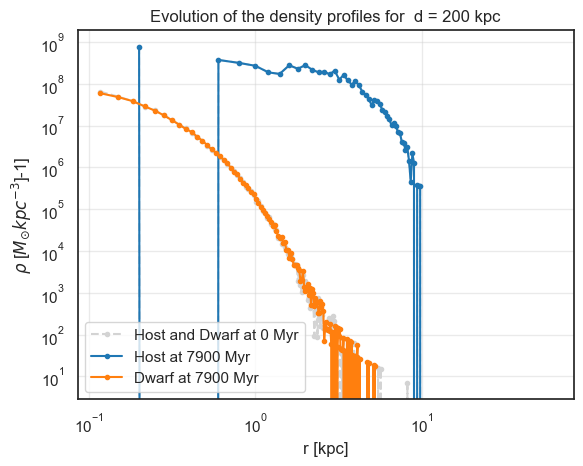

In [ ]:
plt.loglog(bins_host[0], rhos_host[0],  ms=3, marker='o',c = "lightgrey", ls = "dashed", label=f"Host and Dwarf at {t[0]} Myr")
plt.loglog(bins_sat[0], rhos_sat[0],   ms=3, marker='o', c = "lightgrey", ls = "dashed")
plt.loglog(bins_host[-1], rhos_host[-1], ms=3, marker='o', label=f"Host at {t[-1]} Myr")
plt.ylabel("$\\rho$ [$M_{\odot} kpc^{-3}$]-1]")
plt.loglog(bins_sat[-1], rhos_sat[-1], ms=3, marker='o',label=f"Dwarf at {t[-1]} Myr")
plt.legend()
plt.grid(True, alpha=0.4)
plt.xlabel("r [kpc]")
plt.title(f"Evolution of the density profiles for  d = {x0} kpc")
plt.show()

In [ ]:
t_min, r_min, tmax, rmax, e = get_perigalacticon(t, rs)
print(e)

Found minima at times: [4530.11248945]
Values at minima: [203.10213112]
Found minima at times: [1649.06563589 7422.13856454]
Values at minima: [212.16521905 212.25761318]
0.021824706233526007


<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
/var/folders/n1/wqp51b41733bm3stn84s07h40000gn/T/ipykernel_23616/1465506226.py:4: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("Mass [$M_{\odot}$]")


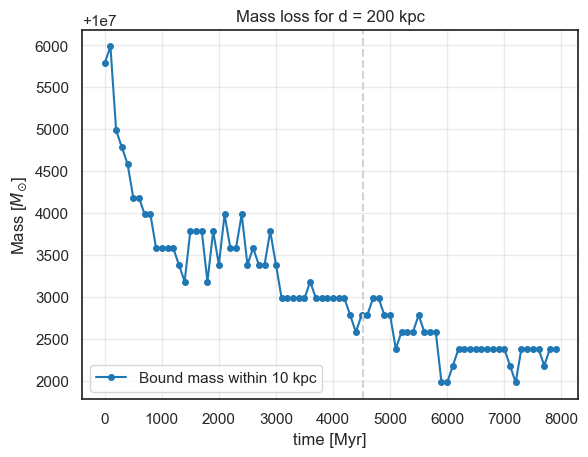

In [ ]:
plt.plot(t, masses_sat,  ms=4, marker='o',label="Bound mass within 10 kpc")
for i in range(len(t_min)):
    plt.axvline(t_min[i], 0, np.max(masses_sat), color = "lightgrey", ls = "dashed")
plt.ylabel("Mass [$M_{\odot}$]")
plt.xlabel("time [Myr]")
plt.title(f"Mass loss for d = {x0} kpc")
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/n1/wqp51b41733bm3stn84s07h40000gn/T/ipykernel_23616/1551941125.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sigma_{dwarf}$ [km/s]")


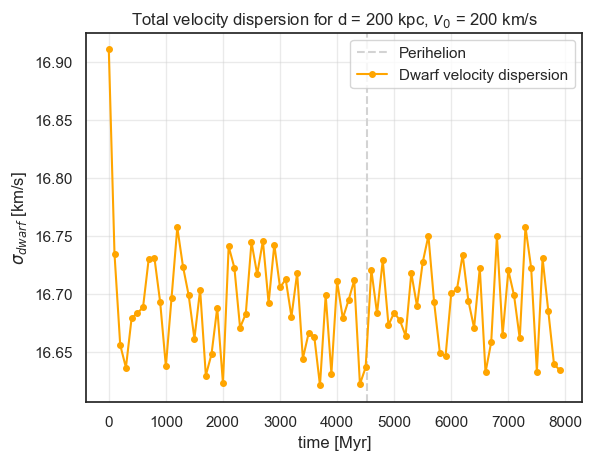

In [ ]:
for i in range(len(t_min)):
    plt.axvline(t_min[i], 0, np.max(sigmas), color = "lightgrey", ls = "dashed", label="Perihelion")
plt.plot(t, sigmas, c="orange",   ms=4, marker='o',label="Dwarf velocity dispersion")
plt.ylabel("$\sigma_{dwarf}$ [km/s]")
plt.xlabel("time [Myr]")
plt.title(f"Total velocity dispersion for d = {x0} kpc, $v_0$ = {vy} km/s")
plt.grid(True, alpha=0.4)
plt.legend()
#plt.savefig(f'{d}change_sigma', dpi=300)
plt.show()

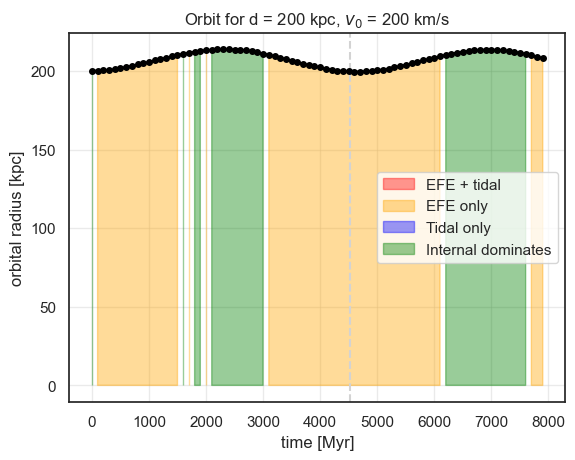

In [ ]:
for i in range(len(t_min)):
    plt.axvline(t_min[i], 0, np.max(rs), color = "lightgrey", ls = "dashed")
plt.plot(t, rs, c="k", marker = "o",  ms=4)
plt.ylabel("orbital radius [kpc]")

plt.xlabel("time [Myr]")
plt.title(f"Orbit for d = {x0} kpc
plt.fill_between(t, 0, rs, where=beta_mask & alpha_mask,  color="red",    alpha=0.4, label="EFE + tidal")
plt.fill_between(t, 0, rs, where=beta_mask , $v_0$ = {vy} km/s")
plt.grid(True, alpha=0.4)

beta_mask  = np.array(betas)  < 1
alpha_mask = np.array(alphas) < 1& ~alpha_mask, color="orange", alpha=0.4, label="EFE only")
plt.fill_between(t, 0, rs, where=~beta_mask & alpha_mask, color="blue",   alpha=0.4, label="Tidal only")
plt.fill_between(t, 0, rs, where=~beta_mask & ~alpha_mask, color="green",   alpha=0.4, label="Internal dominates")
plt.legend()
plt.show()

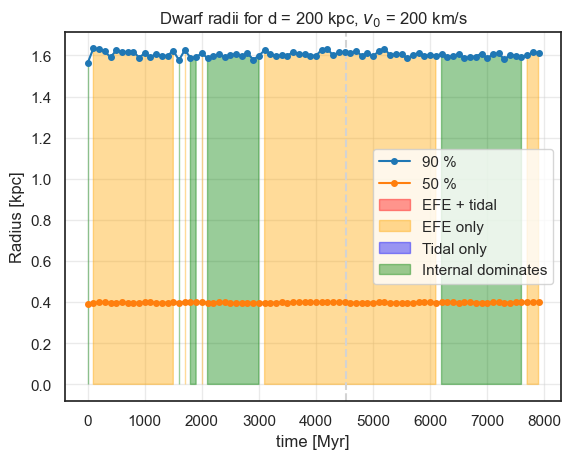

In [ ]:
for i in range(len(t_min)):
    plt.axvline(t_min[i], 0, np.max(lag_sat), color = "lightgrey", ls = "dashed")
plt.plot(t, lag_sat, marker = "o",  ms=4, label="90 %")
plt.plot(t, hmr_sat, marker = "o",  ms=4, label="50 %")
plt.ylabel("Radius [kpc]")
plt.xlabel("time [Myr]")
plt.title(f"Dwarf radii for d = {x0} kpc, $v_0$ = {vy} km/s")
plt.grid(True, alpha=0.4)
plt.fill_between(t, 0, lag_sat, where=beta_mask & alpha_mask,  color="red",    alpha=0.4, label="EFE + tidal")
plt.fill_between(t, 0, lag_sat, where=beta_mask & ~alpha_mask, color="orange", alpha=0.4, label="EFE only")
plt.fill_between(t, 0, lag_sat, where=~beta_mask & alpha_mask, color="blue",   alpha=0.4, label="Tidal only")
plt.fill_between(t, 0, lag_sat, where=~beta_mask & ~alpha_mask, color="green",   alpha=0.4, label="Internal dominates")
plt.legend()
plt.show()

Found minima at times: [4530.11248945]
Values at minima: [203.10213112]
Found minima at times: [1649.06563589 7422.13856454]
Values at minima: [212.16521905 212.25761318]
0.021824706233526007

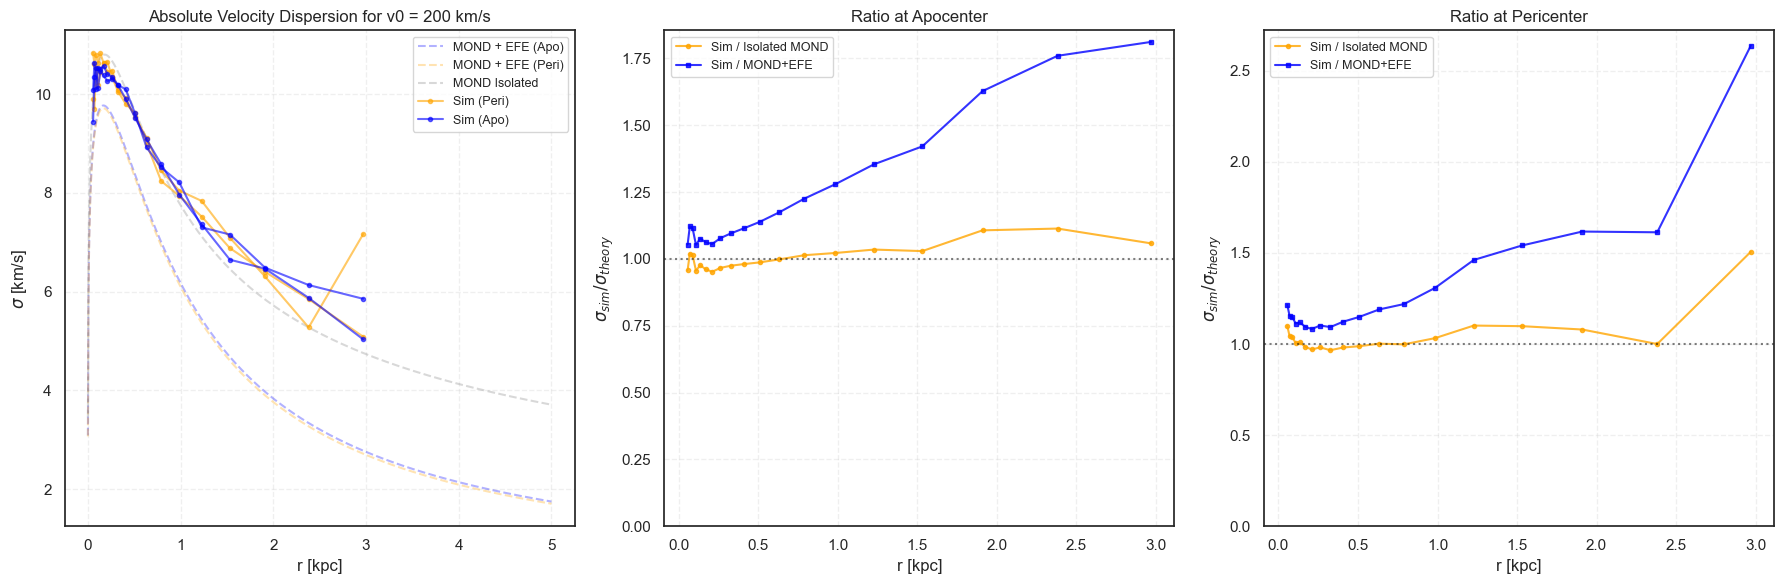

In [ ]:
r_fine = np.linspace(0, 5000, 1000) # pc

sig_mond_apo = get_sigma(r_fine, M=1e7, a_p=0, n=1, r_e=300, profile="sersic", R=212, M_host=8.4e10, mond=True, n_table=1000, efe=False)
sig_mond_apo_efe = get_sigma(r_fine, M=1e7, a_p=0, n=1, r_e=300, profile="sersic", R=212, M_host=8.4e10, mond=True, n_table=1000, efe=True)
sig_mond_peri = get_sigma(r_fine, M=1e7, a_p=0, n=1, r_e=300, profile="sersic", R=200, M_host=8.4e10, mond=True, n_table=1000, efe=False)
sig_mond_peri_efe = get_sigma(r_fine, M=1e7, a_p=0, n=1, r_e=300, profile="sersic", R=200, M_host=8.4e10, mond=True, n_table=1000, efe=True)

r_sim_pc = r_centers * 1e3 
sig_mond_iso = get_sigma(r_sim_pc, M=1e7, a_p=0, n=1, r_e=300, profile="sersic", R=200, M_host=8.4e10, mond=True, n_table=1000, efe=False)
sig_mond_apo_efe_sim = get_sigma(r_sim_pc, M=1e7, a_p=0, n=1, r_e=300, profile="sersic", R=212, M_host=8.4e10, mond=True, n_table=1000, efe=True)
sig_mond_peri_efe_sim = get_sigma(r_sim_pc, M=1e7, a_p=0, n=1, r_e=300, profile="sersic", R=200, M_host=8.4e10, mond=True, n_table=1000, efe=True)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

ax = axs[0]
ax.plot(r_fine/1e3, sig_mond_apo_efe, c="blue", alpha=0.3, ls="--", label="MOND + EFE (Apo)")
ax.plot(r_fine/1e3, sig_mond_peri_efe, c="orange", alpha=0.3, ls="--", label="MOND + EFE (Peri)")
ax.plot(r_fine/1e3, sig_mond_peri, c="grey", alpha=0.3, ls="--", label="MOND Isolated")
peri_indices = [0, 45]
apo_indices = [16, 74]
for idx in peri_indices:
    ax.plot(r_centers, sigmas_bin[idx], color="orange", alpha=0.6, ms=3, marker='o', label="Sim (Peri)" if idx==peri_indices[0] else "")
for idx in apo_indices:
    ax.plot(r_centers, sigmas_bin[idx], color="blue", alpha=0.6, ms=3, marker='o', label="Sim (Apo)" if idx==apo_indices[0] else "")
ax.set_ylabel(r"$\sigma$ [km/s]")
ax.set_xlabel("r [kpc]")
ax.set_title(f"Absolute Velocity Dispersion for v0 = {vy} km/s")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, ls='--')

ax = axs[1]
idx_apo = 16
eps = 1e-5
valid = sig_mond_iso > eps
ratio_apo_iso = np.full_like(sigmas_bin[idx_apo], np.nan)
ratio_apo_efe = np.full_like(sigmas_bin[idx_apo], np.nan)
ratio_apo_iso[valid] = sigmas_bin[idx_apo][valid] / sig_mond_iso[valid]
ratio_apo_efe[valid] = sigmas_bin[idx_apo][valid] / sig_mond_apo_efe_sim[valid]
ax.plot(r_centers, ratio_apo_iso, color="orange", alpha=0.8, ms=3, marker='o', label="Sim / Isolated MOND")
ax.plot(r_centers, ratio_apo_efe, color="blue", alpha=0.8, ms=3, marker='s', label="Sim / MOND+EFE")
ax.axhline(1.0, color='black', ls=':', alpha=0.5)
ax.set_ylabel(r"$\sigma_{sim} / \sigma_{theory}$")
ax.set_xlabel("r [kpc]")
ax.set_title(f"Ratio at Apocenter") 
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, ls='--')
ax.set_ylim(bottom=0)

ax = axs[2]
idx_peri = 0
ratio_peri_iso = np.full_like(sigmas_bin[idx_peri], np.nan)
ratio_peri_efe = np.full_like(sigmas_bin[idx_peri], np.nan)
ratio_peri_iso[valid] = sigmas_bin[idx_peri][valid] / sig_mond_iso[valid]
ratio_peri_efe[valid] = sigmas_bin[idx_peri][valid] / sig_mond_peri_efe_sim[valid]
ax.plot(r_centers, ratio_peri_iso, color="orange", alpha=0.8, ms=3, marker='o', label="Sim / Isolated MOND")
ax.plot(r_centers, ratio_peri_efe, color="blue", alpha=0.8, ms=3, marker='s', label="Sim / MOND+EFE")
ax.axhline(1.0, color='black', ls=':', alpha=0.5)
ax.set_ylabel(r"$\sigma_{sim} / \sigma_{theory}$")
ax.set_xlabel("r [kpc]")
ax.set_title(f"Ratio at Pericenter")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, ls='--')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

In [ ]:
d = "/Volumes/Festplatte/simus/test_new_mw/d_200_0.3/v_100/"
x0 = 200
vx = 0
vy = 100
t_1, all_pos_1, all_vel_1, all_mass_1, rs_1, sigmas_1, masses_host_1, masses_sat_1, rhos_host_1, rhos_sat_1, bins_host_1, bins_sat_1, hmr_sat_1, lag_sat_1, alphas_1, betas_1, r_centers_1, sigmas_bin_1, tidals_1, jacobs_1 = plotting(d, 100, 81,300, x0, y0, vx, vy, N_host=6000, grid_length=500)

/opt/miniconda3/lib/python3.13/site-packages/pynbody/snapshot/ramses.py:836: UserWarning: Using field at offset 9 to distinguish stars. If this is wrong, try editing your config.ini, section [ramses], entry particle-distinguisher.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/pynbody/snapshot/ramses.py:1045: UserWarning: Namelist file either not found or unable to read. Guessing whether run is cosmological from cosmological parameters assuming flat LCDM.
  warnings.warn("Namelist file either not found or unable to read. " +


1000 particles within 60 kpc of [-0.06225505  0.0817002   0.07001263]
  iter 1: N=49998, M=1.001e+07, delta=0.0000
i=1, com_sat: [ 2.00105576e+02  1.44293497e-02 -3.69884390e-02], bound mass: 1.001e+07
1000 particles within 60 kpc of [-0.0728568   0.0972711   0.07198843]
  iter 1: N=49999, M=1.001e+07, delta=0.0000
i=2, com_sat: [ 1.99094807e+02  1.03220936e+01 -1.79600704e-02], bound mass: 1.001e+07
1000 particles within 60 kpc of [-0.10194356  0.15513363  0.11524713]
  iter 1: N=49994, M=1.000e+07, delta=0.0001
i=3, com_sat: [1.96078233e+02 2.05687158e+01 4.91899993e-02], bound mass: 1.000e+07
1000 particles within 60 kpc of [-0.16913989  0.02112214 -0.05444252]
  iter 1: N=49993, M=1.000e+07, delta=0.0001
i=4, com_sat: [ 1.91021238e+02  3.04131309e+01 -9.11012192e-02], bound mass: 1.000e+07
1000 particles within 60 kpc of [-0.15867743  0.02558564 -0.0234246 ]
  iter 1: N=49991, M=1.000e+07, delta=0.0001
i=5, com_sat: [ 1.84016135e+02  4.00710197e+01 -2.96976963e-02], bound mass: 1.0

In [ ]:
t_min, r_min, tmax, rmax, e = get_perigalacticon(t_1, rs_1, factor = 10)

Found minima at times: [1476.62409176 4591.92640441 7660.64128037]
Values at minima: [73.36115307 64.99740966 67.27781418]
Found minima at times: [2982.32744904 6141.27004815]
Values at minima: [201.95939853 200.19992227]


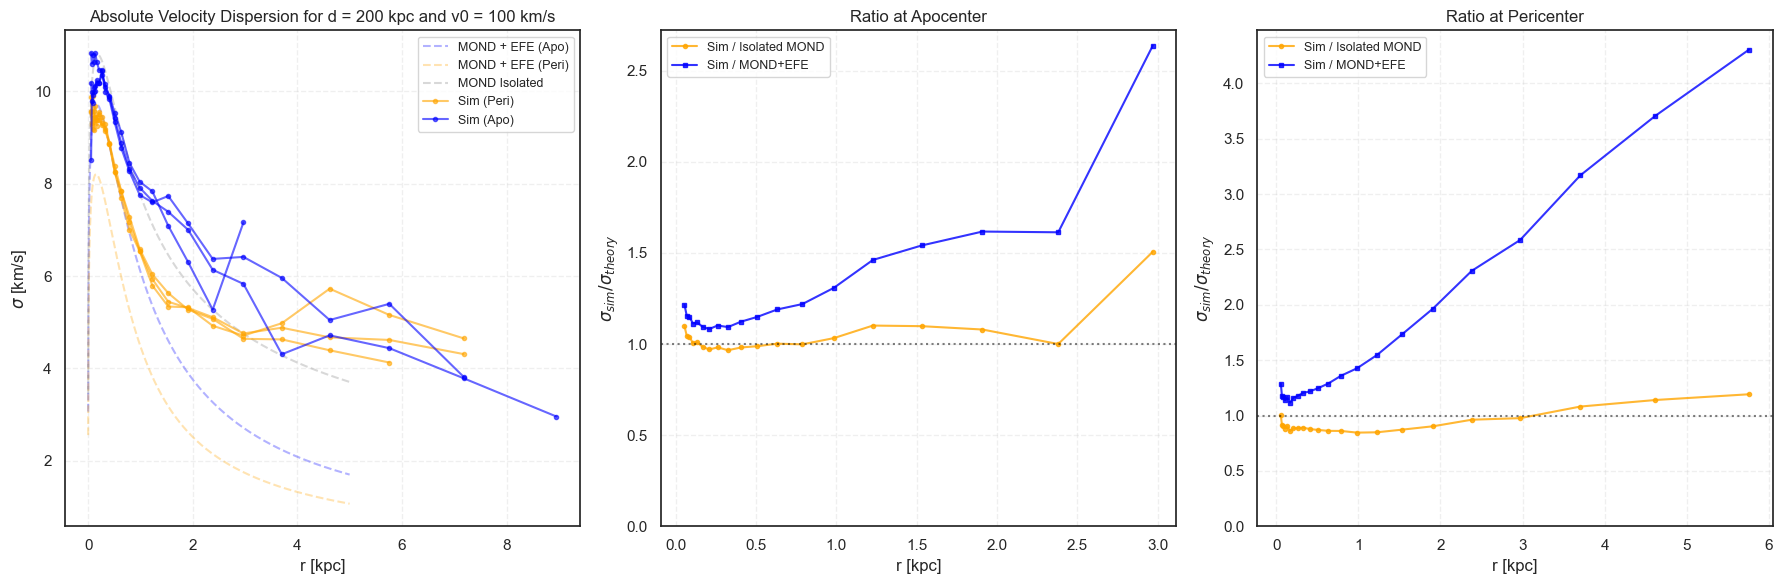

In [ ]:
r_fine = np.linspace(0, 5000, 1000) # pc

sig_mond_apo = get_sigma(r_fine, M=1e7, a_p=0, n=1, r_e=300, profile="sersic", R=200, M_host=8.4e10, mond=True, n_table=1000, efe=False)
sig_mond_apo_efe = get_sigma(r_fine, M=1e7, a_p=0, n=1, r_e=300, profile="sersic", R=200, M_host=8.4e10, mond=True, n_table=1000, efe=True)
sig_mond_peri = get_sigma(r_fine, M=1e7, a_p=0, n=1, r_e=300, profile="sersic", R=70, M_host=8.4e10, mond=True, n_table=1000, efe=False)
sig_mond_peri_efe = get_sigma(r_fine, M=1e7, a_p=0, n=1, r_e=300, profile="sersic", R=70, M_host=8.4e10, mond=True, n_table=1000, efe=True)

r_sim_pc = r_centers_1 * 1e3 
sig_mond_iso = get_sigma(r_sim_pc, M=1e7, a_p=0, n=1, r_e=300, profile="sersic", R=200, M_host=8.4e10, mond=True, n_table=1000, efe=False)
sig_mond_apo_efe_sim = get_sigma(r_sim_pc, M=1e7, a_p=0, n=1, r_e=300, profile="sersic", R=200, M_host=8.4e10, mond=True, n_table=1000, efe=True)
sig_mond_peri_efe_sim = get_sigma(r_sim_pc, M=1e7, a_p=0, n=1, r_e=300, profile="sersic", R=74, M_host=8.4e10, mond=True, n_table=1000, efe=True)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

ax = axs[0]
ax.plot(r_fine/1e3, sig_mond_apo_efe, c="blue", alpha=0.3, ls="--", label="MOND + EFE (Apo)")
ax.plot(r_fine/1e3, sig_mond_peri_efe, c="orange", alpha=0.3, ls="--", label="MOND + EFE (Peri)")
ax.plot(r_fine/1e3, sig_mond_peri, c="grey", alpha=0.3, ls="--", label="MOND Isolated")
peri_indices = [15, 46, 76]
apo_indices = [0, 30, 61]
for idx in peri_indices:
    ax.plot(r_centers_1, sigmas_bin_1[idx], color="orange", alpha=0.6, ms=3, marker='o', label="Sim (Peri)" if idx==peri_indices[0] else "")
for idx in apo_indices:
    ax.plot(r_centers_1, sigmas_bin_1[idx], color="blue", alpha=0.6, ms=3, marker='o', label="Sim (Apo)" if idx==apo_indices[0] else "")
ax.set_ylabel(r"$\sigma$ [km/s]")
ax.set_xlabel("r [kpc]")
ax.set_title("Absolute Velocity Dispersion for d = 200 kpc and v0 = 100 km/s")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, ls='--')

ax = axs[1]
idx_apo = 0 
eps = 1e-5
valid = sig_mond_iso > eps
ratio_apo_iso = np.full_like(sigmas_bin_1[idx_apo], np.nan)
ratio_apo_efe = np.full_like(sigmas_bin_1[idx_apo], np.nan)
ratio_apo_iso[valid] = sigmas_bin_1[idx_apo][valid] / sig_mond_iso[valid]
ratio_apo_efe[valid] = sigmas_bin_1[idx_apo][valid] / sig_mond_apo_efe_sim[valid]
ax.plot(r_centers_1, ratio_apo_iso, color="orange", alpha=0.8, ms=3, marker='o', label="Sim / Isolated MOND")
ax.plot(r_centers_1, ratio_apo_efe, color="blue", alpha=0.8, ms=3, marker='s', label="Sim / MOND+EFE")
ax.axhline(1.0, color='black', ls=':', alpha=0.5)
ax.set_ylabel(r"$\sigma_{sim} / \sigma_{theory}$")
ax.set_xlabel("r [kpc]")
ax.set_title(f"Ratio at Apocenter")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, ls='--')
ax.set_ylim(bottom=0)

ax = axs[2]
idx_peri = 15
ratio_peri_iso = np.full_like(sigmas_bin_1[idx_peri], np.nan)
ratio_peri_efe = np.full_like(sigmas_bin_1[idx_peri], np.nan)
ratio_peri_iso[valid] = sigmas_bin_1[idx_peri][valid] / sig_mond_iso[valid]
ratio_peri_efe[valid] = sigmas_bin_1[idx_peri][valid] / sig_mond_peri_efe_sim[valid]
ax.plot(r_centers_1, ratio_peri_iso, color="orange", alpha=0.8, ms=3, marker='o', label="Sim / Isolated MOND")
ax.plot(r_centers_1, ratio_peri_efe, color="blue", alpha=0.8, ms=3, marker='s', label="Sim / MOND+EFE")
ax.axhline(1.0, color='black', ls=':', alpha=0.5)
ax.set_ylabel(r"$\sigma_{sim} / \sigma_{theory}$")
ax.set_xlabel("r [kpc]")
ax.set_title(f"Ratio at Pericenter")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, ls='--')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

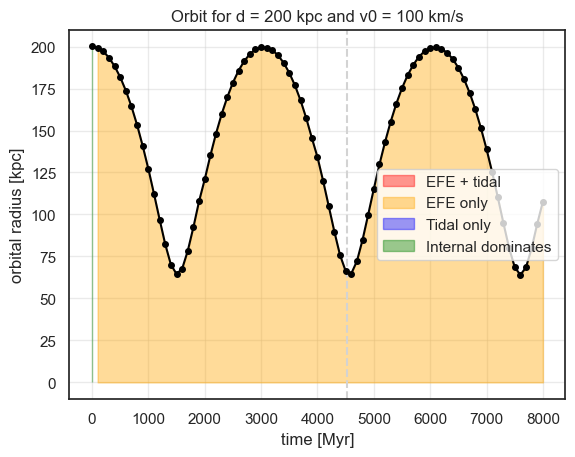

In [ ]:
for i in range(len(t_min)):
    plt.axvline(t_min[i], 0, 500, color = "lightgrey", ls = "dashed")
plt.plot(t_1, rs_1, c="k", marker = "o",  ms=4)
plt.ylabel("orbital radius [kpc]")
plt.xlabel("time [Myr]")
plt.title(f"Orbit for d = 200 kpc and v0 = 100 km/s")
plt.grid(True, alpha=0.4)

beta_mask_2  = np.array(betas_1)  < 1
alpha_mask_2 = np.array(alphas_1) < 1
plt.fill_between(t_1, 0, rs_1, where=beta_mask_2 & alpha_mask_2,  color="red",    alpha=0.4, label="EFE + tidal")
plt.fill_between(t_1, 0, rs_1, where=beta_mask_2 & ~alpha_mask_2, color="orange", alpha=0.4, label="EFE only")
plt.fill_between(t_1, 0, rs_1, where=~beta_mask_2 & alpha_mask_2, color="blue",   alpha=0.4, label="Tidal only")
plt.fill_between(t_1, 0, rs_1, where=~beta_mask_2 & ~alpha_mask_2, color="green",   alpha=0.4, label="Internal dominates")
plt.legend()
plt.show()

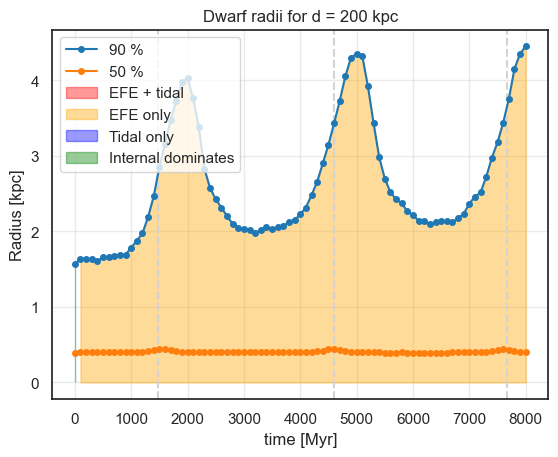

In [ ]:
for i in range(len(t_min)):
    plt.axvline(t_min[i], 0, 500, color = "lightgrey", ls = "dashed")
plt.plot(t_1, lag_sat_1, marker = "o",  ms=4, label="90 %")
plt.plot(t_1, hmr_sat_1, marker = "o",  ms=4, label="50 %")
plt.ylabel("Radius [kpc]")
plt.xlabel("time [Myr]")
plt.title(f"Dwarf radii for d = 200 kpc")
plt.grid(True, alpha=0.4)
plt.fill_between(t_1, 0, lag_sat_1, where=beta_mask_2 & alpha_mask_2,  color="red",    alpha=0.4, label="EFE + tidal")
plt.fill_between(t_1, 0, lag_sat_1, where=beta_mask_2 & ~alpha_mask_2, color="orange", alpha=0.4, label="EFE only")
plt.fill_between(t_1, 0, lag_sat_1, where=~beta_mask_2 & alpha_mask_2, color="blue",   alpha=0.4, label="Tidal only")
plt.fill_between(t_1, 0, lag_sat_1, where=~beta_mask_2 & ~alpha_mask_2, color="green",   alpha=0.4, label="Internal dominates")
plt.legend()
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/n1/wqp51b41733bm3stn84s07h40000gn/T/ipykernel_43197/376628131.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sigma_{dwarf}$ [km/s]")


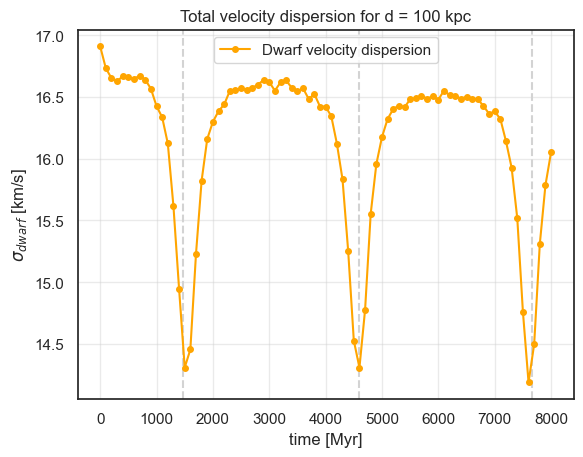

In [ ]:
for i in range(len(t_min)):
    plt.axvline(t_min[i], 0, 500, color = "lightgrey", ls = "dashed")
plt.plot(t_1, sigmas_1, c="orange",   ms=4, marker='o',label="Dwarf velocity dispersion")
plt.ylabel("$\sigma_{dwarf}$ [km/s]")
plt.xlabel("time [Myr]")
plt.title("Total velocity dispersion for d = 100 kpc")
plt.grid(True, alpha=0.4)
plt.legend()
#plt.savefig(f'{d}change_sigma', dpi=300)
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
/var/folders/n1/wqp51b41733bm3stn84s07h40000gn/T/ipykernel_43197/3417649483.py:4: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("Mass [$M_{\odot}$]")


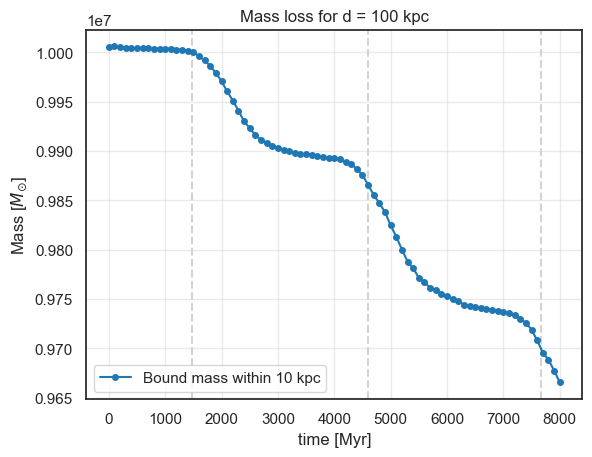

In [ ]:
for i in range(len(t_min)):
    plt.axvline(t_min[i], 0, 500, color = "lightgrey", ls = "dashed")
plt.plot(t_1, masses_sat_1,  ms=4, marker='o',label="Bound mass within 10 kpc")
plt.ylabel("Mass [$M_{\odot}$]")
plt.xlabel("time [Myr]")
plt.title(f"Mass loss for d = 200 kpc")
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

In [ ]:
d = "/Volumes/Festplatte/simus/sersic_0.3_efe/d_200/"
x0 = 200
y0 = 0
vx = 0
vy = 100
t_e, all_pos_e, all_vel_e, all_mass_e, rs_e, sigmas_e, masses_host_e, masses_sat_e, rhos_host_e, rhos_sat_e, bins_host_e, bins_sat_e, hmr_sat_e, lag_sat_e, alphas_e, betas_e, r_centers_e, sigmas_bin_e, tidals_e, jacobs_e = plotting(d, 100, 81,300, x0, y0, vx, vy, N_host=6000, grid_length=500)

/opt/miniconda3/lib/python3.13/site-packages/pynbody/snapshot/ramses.py:836: UserWarning: Using field at offset 9 to distinguish stars. If this is wrong, try editing your config.ini, section [ramses], entry particle-distinguisher.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/pynbody/snapshot/ramses.py:1045: UserWarning: Namelist file either not found or unable to read. Guessing whether run is cosmological from cosmological parameters assuming flat LCDM.
  warnings.warn("Namelist file either not found or unable to read. " +


1000 particles within 60 kpc of [-0.12315128  0.1771587   0.0774837 ]
  iter 1: N=49999, M=1.000e+07, delta=0.0000
i=1, com_sat: [ 2.00040602e+02  1.08438022e-01 -3.67419747e-02], bound mass: 1.000e+07
1000 particles within 60 kpc of [-0.13149826  0.19128141  0.06670218]
  iter 1: N=49988, M=1.000e+07, delta=0.0002
i=2, com_sat: [ 1.99041033e+02  1.04051285e+01 -4.58752174e-02], bound mass: 1.000e+07
1000 particles within 60 kpc of [-0.15631295  0.03011564 -0.04411741]
  iter 1: N=49999, M=1.000e+07, delta=0.0000
i=3, com_sat: [ 1.96037183e+02  2.04230156e+01 -1.53316877e-01], bound mass: 1.000e+07
1000 particles within 60 kpc of [-0.15442578  0.03379883 -0.04038115]
  iter 1: N=49999, M=1.000e+07, delta=0.0000
i=4, com_sat: [ 1.91058034e+02  3.03955904e+01 -1.42659876e-01], bound mass: 1.000e+07
1000 particles within 60 kpc of [-0.09101512  0.01752929 -0.03003701]
  iter 1: N=49998, M=1.000e+07, delta=0.0000
i=5, com_sat: [ 1.84115114e+02  4.00236159e+01 -1.18602475e-01], bound mass: 

In [ ]:
d = "/Volumes/Festplatte/simus/sers_0.75/d_200/"
x0 = 200
y0 = 0
vx = 0
vy = 100
t_7, all_pos_7, all_vel_7, all_mass_7, rs_7, sigmas_7, masses_host_7, masses_sat_7, rhos_host_7, rhos_sat_7, bins_host_7, bins_sat_7, hmr_sat_7, lag_sat_7, alphas_7, betas_7, r_centers_7, sigmas_bin_7, tidals_7, jacobs_7 = plotting(d, 100, 26,300, x0, y0, vx, vy, N_host=6000, grid_length=500)

/opt/miniconda3/lib/python3.13/site-packages/pynbody/snapshot/ramses.py:836: UserWarning: Using field at offset 9 to distinguish stars. If this is wrong, try editing your config.ini, section [ramses], entry particle-distinguisher.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/pynbody/snapshot/ramses.py:1045: UserWarning: Namelist file either not found or unable to read. Guessing whether run is cosmological from cosmological parameters assuming flat LCDM.
  warnings.warn("Namelist file either not found or unable to read. " +


6000 particles within 60 kpc of [ 0.01362609 -0.00871014 -0.0124703 ]
  iter 1: N=49981, M=1.000e+07, delta=0.0001
i=1, com_sat: [2.00013333e+02 5.81986744e-02 6.28719762e-03], bound mass: 1.000e+07
6000 particles within 60 kpc of [-0.01388988  0.02927104  0.00413701]
  iter 1: N=49965, M=9.999e+06, delta=0.0005
i=2, com_sat: [197.79918587  11.71814013  -0.37953524], bound mass: 9.999e+06
6000 particles within 60 kpc of [-0.00449513  0.00930147  0.00343947]
  iter 1: N=49936, M=9.993e+06, delta=0.0010
i=3, com_sat: [195.26864652  21.52007698  -0.87260661], bound mass: 9.993e+06
6000 particles within 60 kpc of [-0.00968549 -0.00396178 -0.00480416]
  iter 1: N=49880, M=9.982e+06, delta=0.0020
i=4, com_sat: [190.28391608  32.35425729  -1.368576  ], bound mass: 9.982e+06
6000 particles within 60 kpc of [1.85337856e-14 2.91848251e-15 1.23095978e-14]
  iter 1: N=49776, M=9.961e+06, delta=0.0034
i=5, com_sat: [182.41995801  41.79570105  -1.43955099], bound mass: 9.961e+06
5999 particles withi

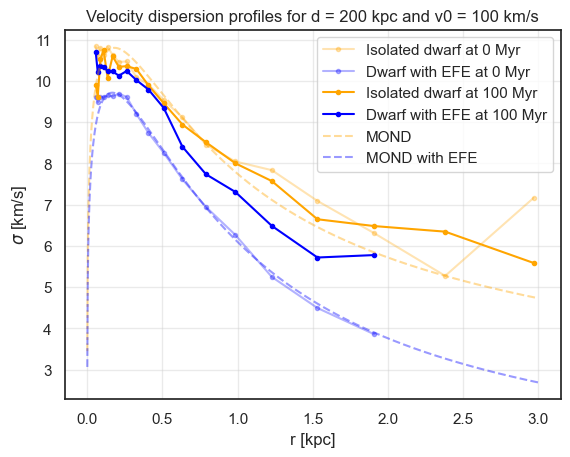

In [ ]:
r = np.linspace(0,3000,1000)
plt.plot(r_centers_1, sigmas_bin_1[0],  alpha = 0.3, c="orange", ms=3, marker='o',label=f"Isolated dwarf at {t_1[0]} Myr")
plt.plot(r_centers_e, sigmas_bin_e[0],  alpha = 0.3, c="blue", ms=3, marker='o',label=f"Dwarf with EFE at {t_e[0]} Myr")
plt.plot(r_centers_1, sigmas_bin_1[1],  c="orange", ms=3, marker='o',label=f"Isolated dwarf at {t_1[1]} Myr")
plt.plot(r_centers_e, sigmas_bin_e[1],  c="blue", ms=3, marker='o',label=f"Dwarf with EFE at {t_e[1]} Myr")
sig_mond = get_sigma(r, M=1e7, a_p=0, n=1, r_e=300, profile="sersic", R=200, M_host=8.4e10, mond=True, n_table=1000,)
sig_mond_efe = get_sigma(r, M=1e7, a_p=0, n=1, r_e=300, profile="sersic", R=200, M_host=8.4e10, mond=True, n_table=1000, efe = True)
plt.plot(r/1e3, sig_mond, c="orange", alpha = 0.4, ls = "dashed", label="MOND")
plt.plot(r/1e3, sig_mond_efe, c="blue", alpha = 0.4, ls = "dashed", label="MOND with EFE ")
plt.ylabel("$\\sigma$ [km/s]")
plt.xlabel("r [kpc]")
plt.title(f"Velocity dispersion profiles for d = 200 kpc and v0 = 100 km/s")
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

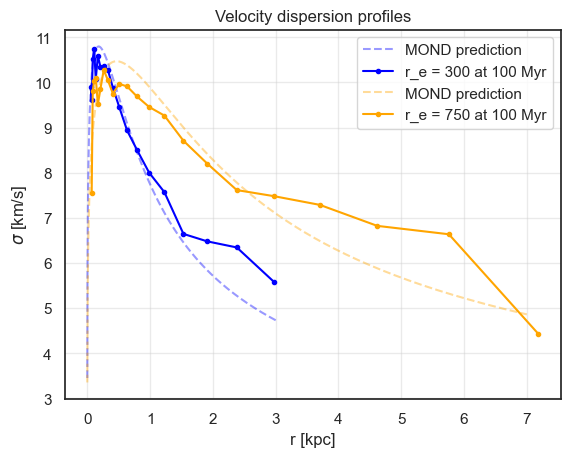

In [ ]:
r=np.linspace(0,3000,1000)
r_7 = np.linspace(0,7000,1000)
sig_mond = get_sigma(r, M=1e7, a_p=0, n=1, r_e=300, profile="sersic", R=200, M_host=8.4e10, mond=True, n_table=1000,)
sig_mond_efe = get_sigma(r_7, M=1e7, a_p=0, n=1, r_e=750, profile="sersic", R=200, M_host=8.4e10, mond=True, n_table=1000)
plt.plot(r/1e3, sig_mond, c="blue", alpha = 0.4, ls = "dashed", label="MOND prediction")
plt.plot(r_centers_1, sigmas_bin_1[1], c="blue", ms=3, marker='o',label=f"r_e = 300 at {t_1[1]} Myr")
plt.plot(r_7/1e3, sig_mond_efe, c="orange", alpha = 0.4, ls = "dashed", label="MOND prediction")
plt.plot(r_centers_7, sigmas_bin_7[1], c="orange", ms=3, marker='o',label=f"r_e = 750 at {t_7[1]} Myr")
plt.ylabel("$\\sigma$ [km/s]")
plt.xlabel("r [kpc]")
plt.title(f"Velocity dispersion profiles")
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

In [8]:
def plotting_pointmass(filename, dt, t_end, boxsize = 600):
    coms_sat = []
    vels_sat = []
    e_orb = []
    rs = []
    times = []
    t = 0
    
    for i in range(1, t_end + 1):
        f = f"{filename}output_{i:05d}"
        s = pn.load(f)
        #pn.analysis.halo.center(s.dm)
        #center around box size 

        r = s.dm["pos"]
        r -= boxsize/2
        rs.append(r)
        v = s.dm['vel'].in_units('km s^-1')
        m = s.dm["mass"]
        com_sat = np.linalg.norm(r, axis = 1)
        vel = np.linalg.norm(v, axis = 1)
        coms_sat.append(com_sat)
        vels_sat.append(vel)
        times.append(t)
        t += dt
    return times, np.array(rs), np.array(coms_sat), np.array(vels_sat)
        

r range:   1.000e-05 to 6.000e+02
rho range: 1.102e-57 to 3.676e+14


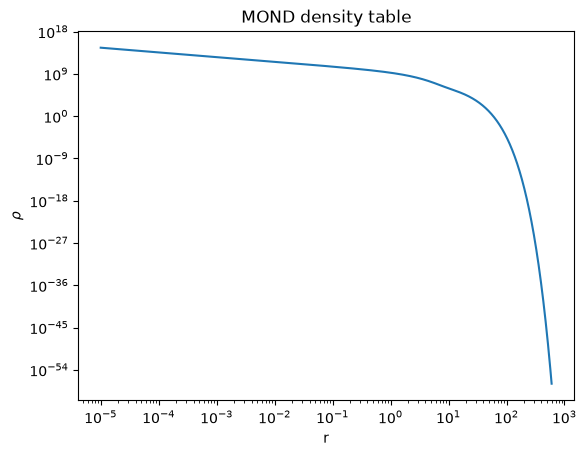

In [ ]:
d = "/Users/olgahinke/simus/tests_new_MW/one_part/mond_density_table.dat"
data = np.loadtxt(d)

r    = data[:, 0]
rho  = data[:, 1]

print(f"r range:   {r.min():.3e} to {r.max():.3e}")
print(f"rho range: {rho.min():.3e} to {rho.max():.3e}")

plt.figure()
plt.loglog(r, rho)
plt.xlabel("r")
plt.ylabel(r"$\rho$")
plt.title("MOND density table")
plt.show()

In [57]:
t, r, com, v = plotting_pointmass("/Users/olgahinke/simus/tests_new_MW/one_part/100/",10, 33, boxsize = 1000)

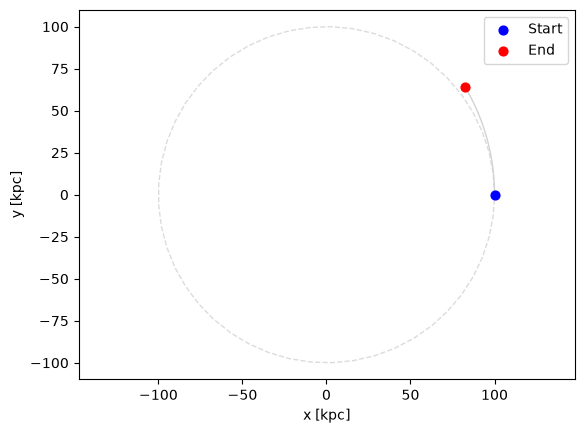

In [62]:
r = np.array(r).squeeze()                             

x = r[:, 0] 
y = r[:, 1] 
z = r[:, 2]
rho = np.linspace(0, 2 * np.pi)
x1 = 100 * np.cos(rho)
y1 = 100 * np.sin(rho)
# x-y plane
plt.plot(x, y, lw=1, color='lightgrey')
plt.plot(x1, y1, lw=1, ls = "dashed", alpha = 0.8, color='lightgrey')
plt.scatter(x[0],  y[0],  color='blue', s=40, zorder=3, label='Start')
plt.scatter(x[-1], y[-1], color='red',   s=40, zorder=3, label='End')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.xlim(-200, 200)
plt.ylim(-200,200)
plt.axis('equal')
plt.legend()
plt.show()


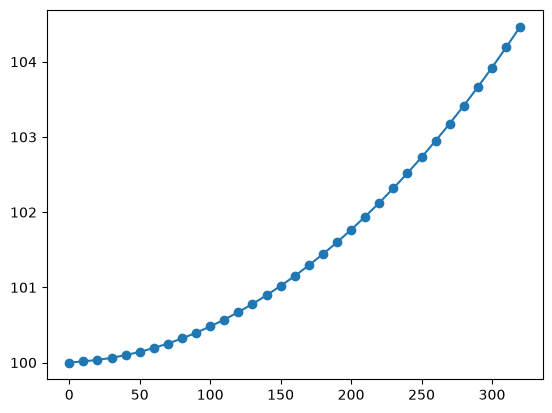

In [63]:
plt.plot(t,com, marker = "o")